# Analisando Fluxo de Balança entre Setores

## Coletando e Limpando Dados ----------------------------------------------------------------

### Importações

In [483]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import statistics
import PIL
import urllib

In [426]:
conn = sqlite3.connect("data/database/ciclus.db")

### "equipamentos" table (ciclus.db)

In [427]:
# Equipamentos
equip = pd.read_sql_query("SELECT * FROM equipamentos;", conn).drop(columns=["extra_info", "numero_serie", "modelo_tecnico", "status_id", "sond_id"])
equip["data_aquisicao"] = pd.to_datetime(equip["data_aquisicao"])
equip["ultima_calibracao"] = pd.to_datetime(equip["ultima_calibracao"])
equip.head()

,id,nome_eq,tipo_eq_id,sigla_eq,setor_id,data_aquisicao,ultima_calibracao,periodicidade,status_calibracao_id,fabricante,modelo
0,1,PRE-MP-001,61,PRE,6,2023-02-02,2025-07-21,12,0,Ownlab,
1,2,PRE-MP-002,61,PRE,6,2024-10-10,2025-07-21,12,0,Wonlab,
2,3,PRE-001,61,PRE,6,2011-05-01,2025-07-21,12,0,Solotest,
3,4,PRE-002,61,PRE,6,2014-04-30,2025-07-21,12,0,Solotest,
4,5,BAL-011,3,BAL,6,2021-01-01,2025-06-12,12,0,Marte científica,5


In [428]:
equip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    273 non-null    int64         
 1   nome_eq               273 non-null    object        
 2   tipo_eq_id            273 non-null    int64         
 3   sigla_eq              273 non-null    object        
 4   setor_id              273 non-null    int64         
 5   data_aquisicao        245 non-null    datetime64[ns]
 6   ultima_calibracao     142 non-null    datetime64[ns]
 7   periodicidade         273 non-null    int64         
 8   status_calibracao_id  273 non-null    int64         
 9   fabricante            273 non-null    object        
 10  modelo                273 non-null    object        
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 23.6+ KB


### "ciclo_vida" table (ciclus.db)

In [429]:
# Ciclo de Vida (tipo = [2, 3, 8])
# 2 = troca de setor
# 3 = quebra
# 8 = descarte
ciclo = pd.read_sql_query("SELECT * FROM ciclo_vida;", conn)
ciclo = ciclo[ciclo["tipo_item_id"].isin([2,3,8])].drop(columns=["valor", "fornecedor"])
ciclo["data"] = pd.to_datetime(ciclo["data"])
ciclo = ciclo.sort_values(by=["equipamento_id", "data"])

ciclo = pd.merge(ciclo, equip[["id", "nome_eq", "sigla_eq"]], left_on="equipamento_id", right_on="id").rename(columns={"id_x":"id_ciclo", "id_y":"id_equip"})
ciclo = ciclo.loc[ciclo["sigla_eq"]=="BAL"]
ciclo

,id_ciclo,equipamento_id,tipo_item_id,descricao,info_especial,data,id_equip,nome_eq,sigla_eq
0,221,6,3,Balança está desbalanceada. Apresenta valores ...,-,2025-09-08,6,BAL-020,BAL
1,322,6,2,Enviado para conserto.,Setor: 6 -> 8,2025-09-23,6,BAL-020,BAL
4,285,54,2,"Troca temporaria para ""dupla"" na compactação.",Setor: 1 -> 6,2025-09-22,54,BAL-010,BAL
7,314,60,2,,Setor: 1 -> 2,2025-09-22,60,BAL-019,BAL
8,313,65,2,,Setor: 1 -> 0,2025-09-22,65,BAL-027,BAL
9,83,69,2,Troca de 'preparação' para 'dosagem',Setor: 4 -> 3,2025-09-02,69,BAL-016,BAL
25,311,116,2,,Setor: 0 -> 1,2025-09-22,116,BAL-026,BAL
26,312,117,2,,Setor: 1 -> 0,2025-09-22,117,BAL-028,BAL
37,300,234,2,Troca temporária de setor por conta de queda d...,Setor: 1 -> 2,2025-09-23,234,BAL-008,BAL
38,306,234,2,Volta para EE2 após troca temporária de setor.,Setor: 2 -> 1,2025-09-24,234,BAL-008,BAL


In [430]:
ciclo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 0 to 57
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_ciclo        24 non-null     int64         
 1   equipamento_id  24 non-null     int64         
 2   tipo_item_id    24 non-null     int64         
 3   descricao       24 non-null     object        
 4   info_especial   24 non-null     object        
 5   data            24 non-null     datetime64[ns]
 6   id_equip        24 non-null     int64         
 7   nome_eq         24 non-null     object        
 8   sigla_eq        24 non-null     object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.9+ KB


## Processamento de Dados ----------------------------------------------------------------

In [431]:
tipos_setor = {
    0: "EE1", # ESPECIAIS 1
    1: "EE2", # ESPECIAIS 2
    2: "SED", # SEDIMENTAÇÃO
    3: "DOS", # DOSAGEM
    4: "PRE", # PREPARAÇÃO
    5: "EST", # ESTOQUE
    6: "COM", # COMPACTAÇÃO
    7: "UFA", # ESTUFA
    8: "NEN", # NENHUM
    9: "CAM" # CAMPO
}

# ----------------------------------EQUIPAMENTO ESPECIFICO----------------------------------

In [453]:
eq_especifico = 235

In [454]:
example = ciclo.loc[ciclo["equipamento_id"] == eq_especifico]
track = []
i = 0
for idx, row in example.iterrows():
    print(row[["data", "tipo_item_id", "descricao", "info_especial"]], end="\n\n\n")
    data = row["data"].date()
    if row["tipo_item_id"] == 2:
        origem = tipos_setor[int(row['info_especial'].split(' ')[1])]
        final = tipos_setor[int(row['info_especial'].split(' ')[3])]
        track.append((i, f"{origem}", data))
        track.append((i, f"{final}", data))
        i = i + 1
    elif row["tipo_item_id"] == 3:
        track.append((i, "quebra", data))
    else:
        track.append((i, "descarte", data))

data                2025-08-06 00:00:00
tipo_item_id                          3
descricao        Fonte quebrada e capa.
info_especial                         -
Name: 39, dtype: object


data                 2025-09-03 00:00:00
tipo_item_id                           2
descricao        Mandado para Preparação
info_especial              Setor: 2 -> 4
Name: 40, dtype: object


data                                           2025-09-21 00:00:00
tipo_item_id                                                     3
descricao        Balança não liga. Continua a mostrar linhas ho...
info_especial                                                    -
Name: 41, dtype: object


data                          2025-09-21 00:00:00
tipo_item_id                                    2
descricao        A espera de conserto no estoque.
info_especial                       Setor: 4 -> 5
Name: 42, dtype: object


data               2025-09-23 00:00:00
tipo_item_id                         2
descricao        Enviado p

In [455]:
resultado = []
contador_setor = -1
ultimo_setor = None

for _, val, data in track:
    if len(val) == 3:  # é setor
        if val != ultimo_setor:  # remove repetição consecutiva
            contador_setor += 1
            resultado.append((contador_setor, val, data))
            ultimo_setor = val
        # se for repetição consecutiva, ignora
    else:  # não é setor
        if contador_setor != -1:
            resultado.append((contador_setor, val, data))
            # NÃO zera mais o ultimo_setor!

print(resultado)

[(0, 'SED', datetime.date(2025, 9, 3)), (1, 'PRE', datetime.date(2025, 9, 3)), (1, 'quebra', datetime.date(2025, 9, 21)), (2, 'EST', datetime.date(2025, 9, 21)), (3, 'NEN', datetime.date(2025, 9, 23))]


## Visualização (with matplotlib) ----------------------------------------------------------------

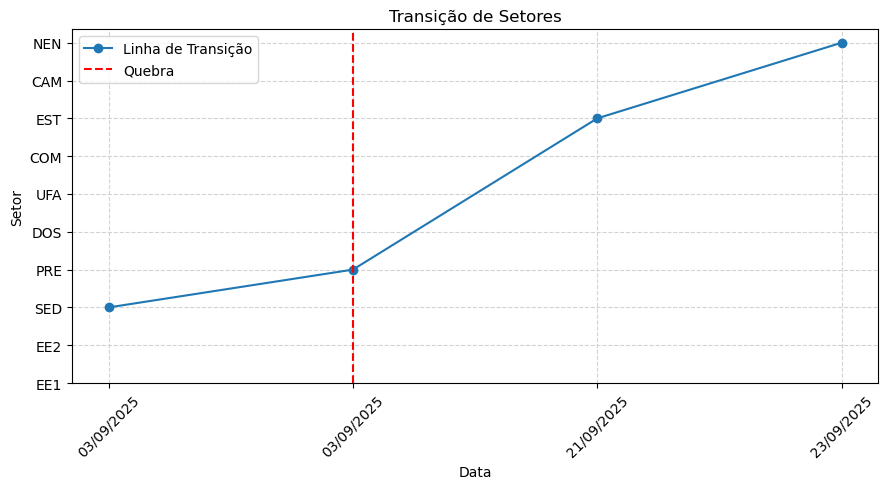

In [456]:
# Dados filtrados (agora com data)
dados_filtrados = [(x, y, data) for x, y, data in resultado if len(y) <= 3]

# Criar mapeamento de setores
setores = ["EE1", "EE2", "SED", "PRE", "DOS", "UFA", "COM", "EST", "CAM", "NEN"]
setor_to_y = {s: i for i, s in enumerate(setores)}

# Eixos X, Y e datas
x = [t[0] for t in dados_filtrados]
y = [setor_to_y[t[1]] for t in dados_filtrados]
x_labels = [t[2].strftime('%d/%m/%Y') for t in dados_filtrados]  # Formata a data

# Plotando o gráfico
plt.figure(figsize=(9, 5))
plt.plot(x, y, marker='o', linestyle='-', label="Linha de Transição")

# Linhas verticais para "quebra" e "descarte"
quant_trans = -1
for idx, val, data in resultado:
    if val == "quebra":
        plt.axvline(x=idx, color='r', linestyle='--', label="Quebra")
    elif val == "descarte":
        plt.axvline(x=idx, color='r', linestyle='--', label="Descarte")
    else:
        quant_trans += 1

# Eixo Y com nomes dos setores
plt.yticks(list(setor_to_y.values()), list(setor_to_y.keys()))

# Substituir os números do eixo X pelas datas
plt.xticks(ticks=x, labels=x_labels, rotation=45)

plt.xlabel("Data")
#plt.xlim(0, dados_filtrados[-1][0])
plt.ylabel("Setor")
plt.title("Transição de Setores")
plt.grid(linestyle="--", color="lightgray")
plt.legend()
plt.tight_layout()
plt.show()

## Calculando Média e Mediana Total ----------------------------------------------------------------

In [436]:
# Dicionário para armazenar os tracks por equipamento
tracks_por_equipamento = {}

# Obter todos os equipamentos únicos
equipamentos_unicos = ciclo["equipamento_id"].unique()

# Loop para cada equipamento
for eq_id in equipamentos_unicos:
    example = ciclo.loc[ciclo["equipamento_id"] == eq_id]
    track = []
    i = 0
    for idx, row in example.iterrows():
        data = row["data"].date()
        if row["tipo_item_id"] == 2:
            origem = tipos_setor[int(row['info_especial'].split(' ')[1])]
            final = tipos_setor[int(row['info_especial'].split(' ')[3])]
            track.append((i, f"{origem}", data))
            track.append((i, f"{final}", data))
            i += 1
        elif row["tipo_item_id"] == 3:
            track.append((i, "quebra", data))
        else:
            track.append((i, "descarte", data))
    
    # Armazenar track do equipamento atual
    tracks_por_equipamento[eq_id] = track

# Dicionário para armazenar o resultado final por equipamento
resultados_por_equipamento = {}

for eq_id, track in tracks_por_equipamento.items():
    resultado = []
    contador_setor = -1
    ultimo_setor = None

    for _, val, data in track:
        if len(val) == 3:  # é setor
            if val != ultimo_setor:  # remove repetição consecutiva
                contador_setor += 1
                resultado.append((contador_setor, val, data))
                ultimo_setor = val
            # se for repetição consecutiva, ignora
        else:  # não é setor
            if contador_setor != -1:
                resultado.append((contador_setor, val, data))
                # NÃO zera mais o ultimo_setor!

    resultados_por_equipamento[eq_id] = resultado  # salva o resultado do equipamento

# MEDIA E MEDIANA

df_trocas = pd.DataFrame.from_dict(contagens_por_equipamento, orient='index', columns=['quantidade_trocas'])

# Se quiser renomear o índice para 'index_equip':
df_trocas.index.name = 'index_equip'

In [466]:
media = df_trocas["quantidade_trocas"].mean()
mediana = df_trocas["quantidade_trocas"].median()
stddev = df_trocas["quantidade_trocas"].std(ddof=0)
print(f"Quantidade de transições do equip escolhido: {quant_trans}")
print(f"Média Total: {media}\nMediana Total: {mediana}\nDesvio Padrão Total: {stddev}")
df_trocas

Quantidade de transições do equip escolhido: 3
Média Total: 1.027027027027027
Mediana Total: 1.0
Desvio Padrão Total: 0.9149357232330139


,quantidade_trocas
index_equip,
6,1
53,2
54,1
55,2
60,1
65,1
69,1
77,0
80,1


In [477]:
df_trocas_count = df_trocas.value_counts().sort_index().reset_index()
df_trocas_count["freq"] = df_trocas_count["count"]/df_trocas_count["count"].sum()
df_trocas_count = df_trocas_count.rename(columns={"count":"contagem", "freq":"frequencia"})
df_trocas_count

,quantidade_trocas,contagem,frequencia
0,0,11,0.297297
1,1,18,0.486486
2,2,4,0.108108
3,3,4,0.108108


## Plotando Histograma e Boxplot

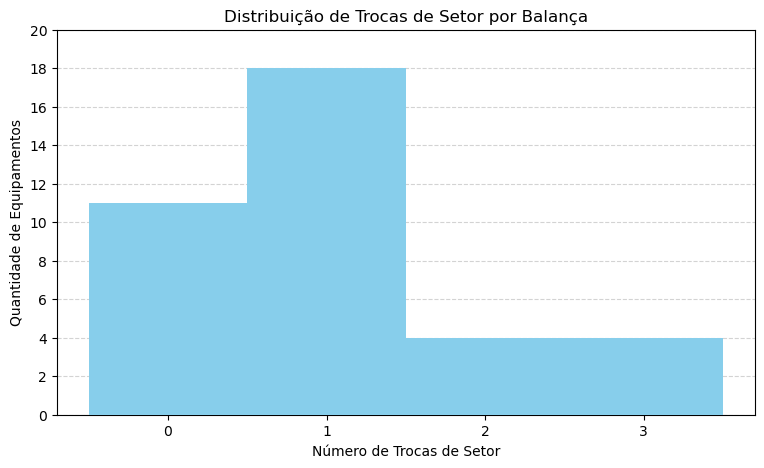

In [447]:
plt.figure(figsize=(9,5))
plt.hist(df_trocas["quantidade_trocas"], bins=range(df_trocas["quantidade_trocas"].max() + 2), 
         color='skyblue', align='left', zorder=3)

plt.title("Distribuição de Trocas de Setor por Balança")
plt.xlabel("Número de Trocas de Setor")
plt.ylabel("Quantidade de Equipamentos")
plt.yticks(np.arange(0,20+1,2))
plt.ylim(0,20)
plt.xticks(range(df_trocas["quantidade_trocas"].max() + 1))
plt.grid(axis='y', linestyle='--', color="lightgray", zorder=0)

plt.show()

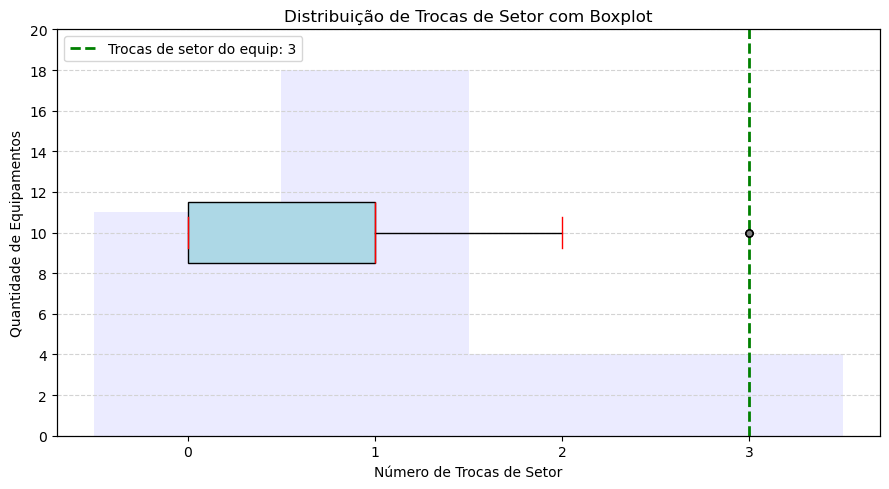

In [465]:
fig, ax = plt.subplots(figsize=(9, 5))

# HISTOGRAMA (no fundo)
ax.hist(df_trocas["quantidade_trocas"], bins=range(df_trocas["quantidade_trocas"].max() + 2),
        color='blue', align='left', zorder=1, alpha=0.08)

# EIXO SECUNDÁRIO pro boxplot (compartilhando o eixo X)
ax_box = ax.twinx()

# BOXPLOT horizontal acima do histograma
ax_box.boxplot(df_trocas["quantidade_trocas"], vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red'),
               whiskerprops=dict(color='black'),
               capprops=dict(color='red'),
               flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, linestyle='none'),
               zorder=2)

# Linha para o equipamento específico
ax.axvline(x=quant_trans, color='green', linestyle='--', linewidth=2, label=f'Trocas de setor do equip: {quant_trans}', zorder=3)

# Limpa eixo Y do boxplot
ax_box.get_yaxis().set_visible(False)

# Estética
ax.set_title("Distribuição de Trocas de Setor com Boxplot")
ax.set_xlabel("Número de Trocas de Setor")
ax.set_xticks(range(df_trocas["quantidade_trocas"].max() + 1))
ax.set_ylabel("Quantidade de Equipamentos")
ax.set_yticks(np.arange(0,20+1,2))
ax.set_ylim(0,20)
ax.grid(axis='y', linestyle='--', color="lightgray",zorder=1)
ax.legend()

plt.tight_layout()
plt.show()


(FILTRAR PARA CONSIDERAR APENAS 1 MÊS DE DELTA t, COMPARANDO AS MÉDIAS DE TRANSPORTES)

### Exemplo de leitura para boxplot:
https://static.wixstatic.com/media/d8f2a2_13ae00396b764d80b0fef53986739ffd~mv2.png/v1/fill/w_550,h_503,al_c/d8f2a2_13ae00396b764d80b0fef53986739ffd~mv2.png

